# Support Vector Machine

SVM은 여러 경계선 후보 중에서 데이터와 가장 여유 있게 떨어진 경계를 찾으려는 모델이다.

1. 데이터를 나누는 경계선을 찾는다.
2. 그 경계선과 가장 가까운 점들까지의 거리를 최대화하려고 한다.
3. 이때 경계에 가장 큰 영향을 주는 점이 서포트 벡터이다.
4. 직선으로 나누기 어렵다면 커널을 사용해 더 유연한 경계를 만든다.

즉, 단순히 나누는 것이 아니라
- 어떤 경계가 더 일반화에 유리한지
- 선형으로 안 나뉘면 어떻게 해결하는지
까지 같이 보는 알고리즘이다.

## 용어 정리

- 초평면(Hyperplane): 데이터를 나누는 기준선 또는 기준면
- 마진(Margin): 경계선과 가장 가까운 점 사이의 여유 거리
- 서포트 벡터(Support Vector): 경계를 결정하는 핵심 점
- 커널(Kernel): 직선으로 안 나뉘는 데이터를 더 잘 나누기 위한 방법

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 01. 선형 SVM

가장 단순한 형태인 선형 커널(linear kernel)부터 확인한다.

- SVM도 결국 분류 모델이다.
- 하지만 단순히 맞히는 것보다 **경계의 여유** 를 중요하게 본다.
- 따라서 로지스틱 회귀와 비슷해 보이지만, 경계를 잡는 방식은 다르다.

In [2]:
# 데이터 준비
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(120, 4) (120,)
(30, 4) (30,)


In [3]:
# 모델 학습/평가
from sklearn.pipeline import Pipeline
# 거리와 마진 개념을 사용하는 모델이므로 특성들의 스케일링이 중요
from sklearn.preprocessing import StandardScaler     
from sklearn.svm import SVC

svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', random_state=42))
])

svm_clf.fit(X_train, y_train)

print(f"학습셋 정확도 : {svm_clf.score(X_train, y_train)}")
print(f"훈련셋 정확도 : {svm_clf.score(X_test, y_test)}")

학습셋 정확도 : 0.975
훈련셋 정확도 : 1.0


### 시각화 전 체크

`DecisionBoundaryDisplay`는 2차원 특성일 때 경계를 그리기 쉽다.  
하지만 iris 데이터는 특성이 4개이므로 그대로는 시각화가 어렵다.

여기서는 **모델 성능을 높이기 위한 차원축소** 보다는 **결정 경계를 눈으로 보기 위한 차원축소**라는 목적으로 PCA를 사용한다.

In [4]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(X_train[:5])
print(X_train_pca[:5])

[[4.4 2.9 1.4 0.2]
 [4.9 2.5 4.5 1.7]
 [6.8 2.8 4.8 1.4]
 [4.9 3.1 1.5 0.1]
 [5.5 2.5 4.  1.3]]
[[-2.90333682 -0.54299974]
 [ 0.49786421 -1.15857037]
 [ 1.3229089   0.22065375]
 [-2.68548399 -0.08921653]
 [ 0.1487804  -0.67542806]]


In [7]:
# 2차원 공간에서 다시 선형 SVM 학습
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train_pca, y_train)

print(f"학습셋 정확도 : {svm_clf.score(X_train_pca, y_train)}")
print(f"훈련셋 정확도 : {svm_clf.score(X_test_pca, y_test)}")

학습셋 정확도 : 0.975
훈련셋 정확도 : 0.9


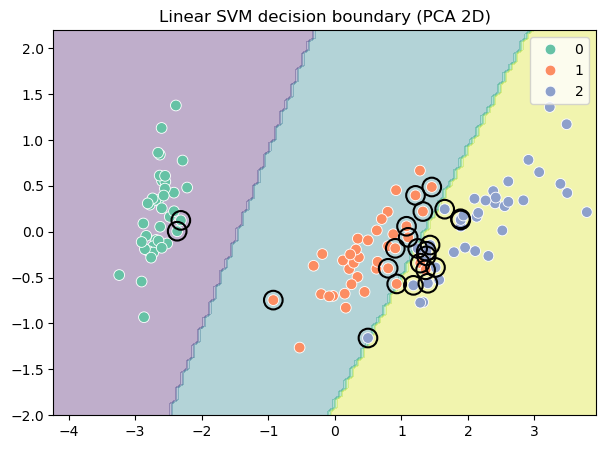

In [10]:
from sklearn.inspection import DecisionBoundaryDisplay

# 선형 SVM 결정 경계 시각화
fig, ax = plt.subplots(figsize=(7, 5))

# 학습 된 모델을 기반으로 각 좌표에 대해 예측값을 계산하여 결정 경계를 색으로 표현
DecisionBoundaryDisplay.from_estimator(
    svm_clf,
    X_test_pca,
    response_method='predict',
    alpha=0.35,
    ax=ax
)

# 실제 데이터 산점도
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette='Set2',
    s=60,
    ax=ax
)

# 서포트 벡터 표시
ax.scatter(
    svm_clf.support_vectors_[:, 0],
    svm_clf.support_vectors_[:, 1],
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='support vectors'
)

ax.set_title('Linear SVM decision boundary (PCA 2D)')
plt.show()

## 02. 비선형 커널

선형 커널은 직선 형태의 경계만 만들 수 있다. 따라서 데이터가 복잡하게 섞여 있으면 직선 하나로는 잘 나누기 어렵다.

이때 등장하는 것이 비선형 커널이다.

- RBF 커널
- 다항 커널
- 시그모이드 커널
등 이 있다.

### RBF 커널 

RBF는 Radial Basis Function의 약자이다.  
직역하면 반지름(거리)을 기준으로 하는 함수라는 의미이다.

즉, 두 점 사이의 거리를 기준으로 얼마나 비슷한지를 판단하는 방식이다.

RBF 커널은 **가까운 점끼리는 비슷하게 보고, 먼 점은 덜 비슷하게 본다** 는 생각으로 이해하면 된다.  
결국 원래 공간에서는 직선으로 잘 안 나뉘는 데이터를, 더 잘 구분할 수 있는 방식으로 바라보게 해 준다.

수식은 다음과 같다.

$$
K(x_i, x_j) = \exp(-\gamma \| x_i - x_j \|^2)
$$

수식 자체보다 해석이 더 중요하다.

- 두 점 사이의 거리가 작다 → exp 값이 1에 가까움 → 매우 비슷함
- 두 점 사이의 거리가 크다 → exp 값이 0에 가까움 → 거의 영향 없음

즉, 거리 기반으로 유사도를 계산하는 함수라고 보면 된다.

- gamma가 크다: 아주 가까운 점에 민감해져서 경계가 복잡해질 수 있다.
- gamma가 작다: 더 넓게 보므로 경계가 부드러워질 수 있다.

즉, gamma는 경계가 얼마나 섬세하게 구부러질지를 조절하는 값이라고 볼 수 있다.

In [11]:
# RBF 커널 적용
svm_clf_rbf = SVC(kernel='rbf', gamma='auto', random_state=42)
svm_clf_rbf.fit(X_train_pca, y_train)

print(f"학습셋 정확도:{svm_clf_rbf.score(X_train_pca, y_train)}")
print(f"평가셋 정확도:{svm_clf_rbf.score(X_test_pca, y_test)}")

학습셋 정확도:0.9666666666666667
평가셋 정확도:0.9


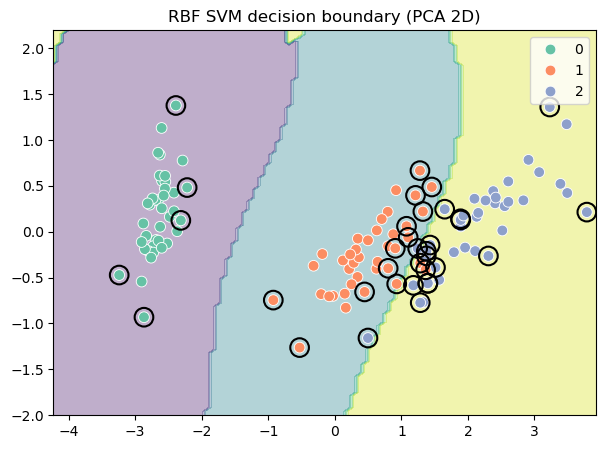

In [12]:
from sklearn.inspection import DecisionBoundaryDisplay

# RBF 커널 SVM 결정 경계 시각화
fig, ax = plt.subplots(figsize=(7, 5))

# 학습 된 모델을 기반으로 각 좌표에 대해 예측값을 계산하여 결정 경계를 색으로 표현
DecisionBoundaryDisplay.from_estimator(
    svm_clf_rbf,
    X_test_pca,
    response_method='predict',
    alpha=0.35,
    ax=ax
)

# 실제 데이터 산점도
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette='Set2',
    s=60,
    ax=ax
)

# 서포트 벡터 표시
ax.scatter(
    svm_clf_rbf.support_vectors_[:, 0],
    svm_clf_rbf.support_vectors_[:, 1],
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='support vectors'
)

ax.set_title('RBF SVM decision boundary (PCA 2D)')
plt.show()

## 03. gamma 변경 테스트

SVM에서 하이퍼파라미터가 `gamma`는

- 너무 작으면: 경계가 너무 단순해져서 패턴을 놓칠 수 있다.
- 너무 크면: 훈련 데이터에만 지나치게 맞춰져 과적합될 수 있다.

In [13]:
# gamma 값 변화에 따른 성능 비교
for gamma in [0.01, 0.1, 1, 10]:
    model = SVC(kernel='rbf', gamma=gamma, random_state=42)
    model.fit(X_train_pca, y_train)

    print(f'gamma={gamma}')
    print(f'학습셋 정확도={model.score(X_train_pca, y_train)}')
    print(f'평가셋 정확도={model.score(X_test_pca, y_test)}')
    print()

gamma=0.01
학습셋 정확도=0.9083333333333333
평가셋 정확도=0.9

gamma=0.1
학습셋 정확도=0.975
평가셋 정확도=0.9333333333333333

gamma=1
학습셋 정확도=0.9666666666666667
평가셋 정확도=0.9

gamma=10
학습셋 정확도=0.9833333333333333
평가셋 정확도=0.9333333333333333



## 04. C 하이퍼파라미터 

RBF SVM에서는 gamma 외에도 C라는 중요한 하이퍼파라미터가 있다.

- C가 크다:
  - 분류 오류를 덜 허용하려고 한다.
  - 훈련 데이터를 더 엄격하게 맞추려 한다.
  - 경계가 복잡해질 수 있고 과적합 위험이 커질 수 있다.

- C가 작다:
  - 일부 오류를 허용한다.
  - 조금 더 여유 있는 경계를 만들 수 있다.
  - 일반화에는 유리할 수 있지만 너무 작으면 충분히 학습하지 못할 수 있다.

정리하면,
- gamma = 경계의 형태를 얼마나 세밀하게 볼 것인가
- C = 오차를 얼마나 엄격하게 줄일 것인가

두 값은 함께 모델의 복잡도와 일반화 성능에 영향을 준다.

In [14]:
# C 값 변화에 따른 성능 비교
for C in [0.1, 1, 10, 100]:
    model = SVC(kernel='rbf', gamma=0.1, C=C, random_state=42)
    model.fit(X_train_pca, y_train)

    print(f'C={C}')
    print(f'학습셋 정확도={model.score(X_train_pca, y_train)}')
    print(f'평가셋 정확도={model.score(X_test_pca, y_test)}')
    print()

C=0.1
학습셋 정확도=0.9166666666666666
평가셋 정확도=0.9

C=1
학습셋 정확도=0.975
평가셋 정확도=0.9333333333333333

C=10
학습셋 정확도=0.975
평가셋 정확도=0.9333333333333333

C=100
학습셋 정확도=0.9833333333333333
평가셋 정확도=0.9



## 정리

1. SVM은 단순 분류기라기보다 마진을 크게 가져가는 경계를 찾는 모델이다.
2. 선형 커널은 직선 경계만 만들 수 있다.
3. 데이터가 복잡하면 RBF 같은 비선형 커널이 필요할 수 있다.
4. gamma는 경계의 복잡도를 조절하는 중요한 하이퍼파라미터이다.
5. C는 분류 오차를 얼마나 엄격하게 허용하지 않을지를 조절하는 하이퍼파라미터이다.